In [1]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import matthews_corrcoef, confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
import matplotlib.pyplot as plt
import pandas as pd
import model as m
import seaborn as sns
import divide_bins as divide
import numpy as np
import regression as reg


2024-09-25 15:12:11.408672: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-25 15:12:11.410447: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-25 15:12:11.436176: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-25 15:12:11.436211: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-25 15:12:11.437165: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
file_name = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/outputs/micro_2_Combat_smote_8_classes.csv"
df = pd.read_csv(file_name)
df.columns

Index(['U48705', 'M87338', 'X51757', 'X69699', 'L36861', 'L13852', 'X55005',
       'X79510', 'M21121', 'J02843',
       ...
       'AI654857', 'W22117', 'AI028241', 'AI571298', 'AA149545', 'C18318',
       'AI219073', 'AI205180', 'AI363375', 'Age'],
      dtype='object', length=51277)

In [4]:
root = "/home/karen/Documents/phd/Data/Batch_corrected"
root = "/home/karen/Documents/GitHub/batch_correction/Results"
files = [
    #"micro_z_Combat.csv",
    #"RNAs_2_reCombat.csv",
    #"micro_2_Combat.csv",
    #"micro_z_reCombat.csv",
    #"RNAs_z_Combat.csv",
    #"micro_2_reCombat.csv",
    #"RNAs_2_Combat.csv",
    #"RNAs_z_Combat_2.csv",
    #"RNAs_z_reCombat.csv"
    "RNAseq_z_score_adjustedCombat.csv"
]


In [16]:
def eval_regression_file(f, method="L2"):
    assert method in ["L1", "L2"]
    eval={"File": f}
    if "micro" in f:
        eval["Technology"]="Microarray"
    else:
        eval["Technology"]= "RNAseq"
    
    if "z" in f:
        eval["Normalization"]= "Z-score"
    else:
        eval["Normalization"]="Two-step"
    
    if "reCombat" in f:
        eval["BatchCorrection"]= "reCombat"
    else:
        eval["BatchCorrection"]="Combat"
        
    dataset = pd.read_csv(f"{root}/{f}")
    section_df = dataset.drop(columns=["Age"])
    section_df_age = dataset["Age"]
    section_df = m.remove_non_numeric_columns(section_df)
    if method == "L2":
        result_df, result_metrics, ridge_model = reg.ridge_L2(X=section_df, y=section_df_age, z=dataset["Experiment"], test_size=0.4)
    elif method == "L1":
        result_df, result_metrics, _ = reg.lasso_L1(X=section_df, y=section_df_age, z=dataset["Experiment"])
    age_ranges = divide.get_age_distribution(result_df["Actual"], age_ranges=[18, 26,35,65,71,72,95])
    y_train_cat = result_df["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
    y_test_cat = result_df["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))

    cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
    mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])
    result_metrics["MCC"]= mcc
    # area under the curve
    auc = accuracy_score(cat_results["Actual"], cat_results["Predicted"])
    result_metrics["AUC"] = auc
    eval.update(result_metrics)

    return eval, result_df, ridge_model


In [17]:
file = files[0]

eval, result_df_rnaseq, ridge_model = eval_regression_file(file, method="L2")

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [18]:
# save ridge_model on pkl file
import pickle
with open("ridge_model.pkl", "wb") as f:
    pickle.dump(ridge_model, f)
    

In [19]:
eval

{'File': 'RNAseq_z_score_adjustedCombat.csv',
 'Technology': 'RNAseq',
 'Normalization': 'Z-score',
 'BatchCorrection': 'Combat',
 'Method': 'Ridge Regression',
 'MSE': 35.37523895974155,
 'RMSE': 5.9477087151054695,
 'MAE': 4.493658904288214,
 'R2': 0.9231157945621292,
 'MCC': 0.4679106113791107,
 'AUC': 0.5370370370370371}

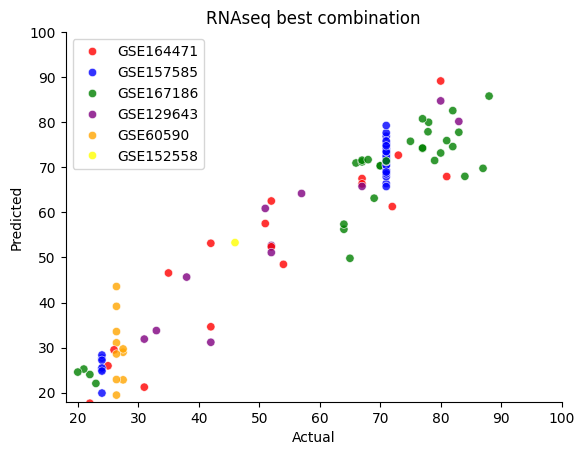

In [15]:
results = result_df_rnaseq
custom_palette = {
        'GSE164471': 'red',
        'GSE157585': 'blue',
        'GSE167186': 'green',
        'GSE129643': 'purple',
        'GSE60590': 'orange',
        'GSE152558': 'yellow'
    }

label_order = ['GSE164471', 'GSE157585', 'GSE167186', 'GSE129643', 'GSE60590', 'GSE152558']

sns.scatterplot(x='Actual', y='Predicted', hue='Group', data=results, palette=custom_palette, hue_order=label_order, alpha=0.8, edgecolor='w')

#plt.scatter(y_test, ridge.predict(X_test), hue=z, label='Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RNAseq best combination')
plt.xlim(18, 100)
plt.ylim(18, 100)
plt.legend()


# Get the current axes object
ax = plt.gca()

# Remove the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Show the plot
plt.savefig("RNAseq_best_combination.png")

plt.show()

In [20]:
result_df_rnaseq

,Actual,Predicted,Group
30,35.0,46.563225,GSE164471
116,24.0,25.491982,GSE157585
79,71.0,69.332486,GSE157585
127,24.0,19.918996,GSE157585
196,77.0,74.200361,GSE167186
...,...,...,...
108,71.0,74.779770,GSE157585
140,64.0,57.386531,GSE167186
173,20.0,24.577819,GSE167186
262,83.0,80.181959,GSE129643


In [49]:
age_ranges = divide.get_age_distribution(result_df_rnaseq["Actual"], age_ranges=[16, 26,35,65,71,72,96])
age_ranges

[{'label': '16-26', 'range': (16, 26), 'count': 16},
 {'label': '26-35', 'range': (26, 35), 'count': 14},
 {'label': '35-65', 'range': (35, 65), 'count': 16},
 {'label': '65-71', 'range': (65, 71), 'count': 41},
 {'label': '71-72', 'range': (71, 72), 'count': 1},
 {'label': '72-96', 'range': (72, 96), 'count': 20}]

In [50]:
y_train_cat = result_df_rnaseq["Actual"].apply(lambda x: divide.assign_age_group(x, age_ranges))
y_test_cat = result_df_rnaseq["Predicted"].apply(lambda x: divide.assign_age_group(x, age_ranges))


cat_results = pd.DataFrame({"Actual": y_train_cat, "Predicted": y_test_cat})
#mcc = matthews_corrcoef(result_df_rnaseq["Actual"], result_df_rnaseq["Predicted"])



In [57]:
mcc = matthews_corrcoef(cat_results["Actual"], cat_results["Predicted"])


In [58]:
cat_results=cat_results[cat_results["Predicted"]!="Unknown"]

In [59]:
confusion_matrix_table = confusion_matrix(cat_results["Actual"], cat_results["Predicted"])
confusion_matrix_table

array([[12,  3,  0,  0,  0,  0],
       [ 4,  8,  2,  0,  0,  0],
       [ 0,  2, 14,  0,  0,  0],
       [ 0,  0,  2,  6,  3,  0],
       [ 0,  0,  0, 10,  4, 17],
       [ 0,  0,  1,  3,  1, 16]])

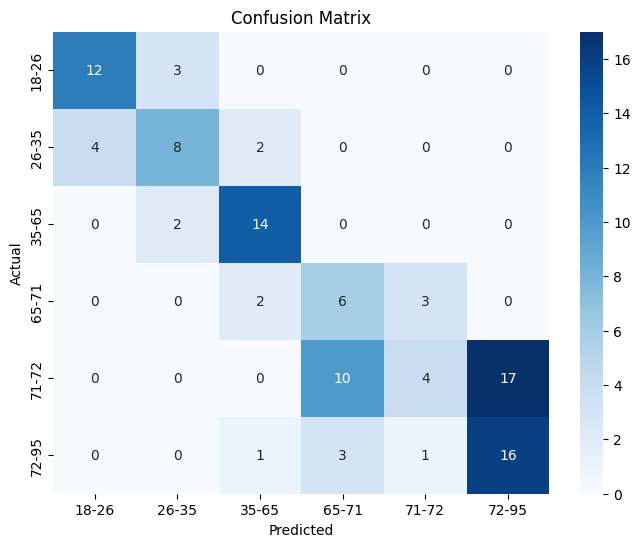

In [63]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_table, cmap='Blues', 
 xticklabels=["18-26", "26-35","35-65","65-71","71-72","72-95"], yticklabels=["18-26", "26-35","35-65","65-71","71-72","72-95"], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix_ridge.png")
plt.show()